# Certamen 1 — Parte Práctica
## Machine Learning (EIN143A25) · Paralelo 701 · Semestre 2026-2

**Docente:** Diego Ramírez · **Unidad 1: Fundamentos y Preparación**
**Puntaje:** 40 puntos de los 100 del Certamen 1 · **Entrega:** Domingo 13 de septiembre de 2026, 23:59, vía AULA-USM

**Nombre:** _(escribe tu nombre aquí)_

---

### Reglas

- Trabajo **individual**. Puedes usar tus apuntes, los notebooks del curso y la documentación de `scikit-learn`.
  No puedes compartir código con tus compañeros ni entregar código que no seas capaz de explicar.
- Cada decisión debe venir justificada en la celda markdown correspondiente. **El código correcto sin
  justificación obtiene puntaje parcial**: en esta unidad se evalúa el criterio, no la sintaxis.
- Antes de entregar: `Kernel → Restart & Run All`. Un notebook que no corre de arriba a abajo pierde 3 puntos.
- Nombre del archivo: `Certamen1_Practica_apellido_nombre.ipynb`

### Contenido

| Parte | Tema | Dataset | Puntos |
|---|---|---|:---:|
| A | Preparación honesta de un dataset sucio | Titanic | 22 |
| B | Selección vs. extracción de características y validación cruzada | Breast Cancer | 18 |

---
# Parte A · Preparación honesta de datos (22 puntos)

Titanic es lo contrario de Wine: tiene nulos, tiene variables de texto, tiene columnas redundantes y
tiene al menos una trampa. Es el tipo de dataset con el que se trabaja fuera de la sala de clases.

In [1]:
! pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Opción 1 (con internet):
import seaborn as sns
df = sns.load_dataset("titanic")

# Opción 2 (sin internet): usa el CSV del Laboratorio 03
# df = pd.read_csv("titanic.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### A1 · Diagnóstico del dataset (4 pts)

**Tu tarea:**

1. Reporta `df.shape`.
2. Cuenta los nulos por columna y ordénalos de mayor a menor.
3. Muestra la distribución del target `survived`, en proporción.

In [15]:
print("Dimensiones del DataFrame:", df.shape)

nulos = df.isnull().sum().sort_values(ascending=False)
print("\nValores nulos por columna:")
print(nulos)

print("\nDistribución de survived (proporción):")
print(df['survived'].value_counts(normalize=True))

Dimensiones del DataFrame: (891, 15)

Valores nulos por columna:
deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

Distribución de survived (proporción):
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


**Responde aquí:** nombra **dos problemas concretos** de preparación que tiene este dataset y que
Wine no tenía. Para cada uno, indica en qué clase de la unidad vimos cómo tratarlo.

> *(tu respuesta)*

In [ ]:
Dos problemas específicos que presenta el Titanic y que Wine no presentaba son los valores ausentes nulos y las variables de texto categóricas. Los valores nulos los discutimos en la lección de limpieza de datos, donde aprendi que no se pueden eliminar porque se pierde información valiosa. Las variables de texto las abordamos en la clase de codificación, dado que los modelos de Machine Learning no comprenden letras ni palabras, solo números, por lo que es necesario transformarlas.

### A2 · Valores faltantes (5 pts)

**Tu tarea:** decide una estrategia **por columna** para las tres columnas con nulos y aplícala.
No uses la misma receta para todas: cada una tiene una situación distinta.

En la celda de respuesta debes justificar, para cada columna, **por qué** elegiste esa estrategia y
qué habrías perdido con la alternativa.

In [33]:
df_lim = df.copy()

df_lim = df_lim.drop(columns=['deck'])

df_lim['embarked'] = df_lim['embarked'].fillna(df_lim['embarked'].mode()[0])
df_lim['embark_town'] = df_lim['embark_town'].fillna(df_lim['embark_town'].mode()[0])

df_lim['age'] = df_lim['age'].fillna(df_lim['age'].median())

print("Nulos restantes:", df_lim.isnull().sum().sum())

Nulos restantes: 0


**Responde aquí:** justifica cada una de las tres decisiones. En el caso de `age`, ¿por qué
mediana y no media? ¿Y por qué no eliminar simplemente las filas con `age` nula?

> *(tu respuesta)*

In [ ]:
Le quité toda la columna a deck porque faltaba más de la mitad de la información; inventar datos crearía una historia falsa sobre el barco. A embarked le añadí la moda, ya que había pocos casos sin información, y elegir el puerto más frecuente parecía lógico. Usé la mediana para la edad, ya que es más resistente a números extremos, sin eliminar filas para no perder pasajeros valiosos.

### A3 · Variables categóricas y columnas tramposas (4 pts)

**Cuidado:** este dataset trae columnas que son **el mismo target escrito de otra forma**. Si las dejas,
tu modelo obtendrá casi 100 % y no habrá aprendido nada — será otra forma de hacer trampa.

**Tu tarea:**

1. Revisa las columnas que quedan (`df_lim.columns`) e identifica cuáles hay que **eliminar** por
   filtrar el target o por ser duplicados de otra columna.
2. Codifica las categóricas restantes. Distingue explícitamente **nominales** (One-Hot) de
   **ordinales** (un número que preserve el orden).
3. Deja armados `X` (features) e `y` (target).

In [38]:
df_lim = df_lim.drop(columns=['alive', 'embark_town', 'class', 'who', 'adult_male'], errors='ignore')

if 'sex' in df_lim.columns:
    df_lim['sex'] = df_lim['sex'].map({'male': 0, 'female': 1})
if 'alone' in df_lim.columns:
    df_lim['alone'] = df_lim['alone'].astype(int)
if 'embarked' in df_lim.columns:
    df_lim = pd.get_dummies(df_lim, columns=['embarked'], drop_first=True)

X = df_lim.drop(columns=['survived']).select_dtypes(include=['number'])
y = df_lim['survived']

print("¡Listo! Columnas de X:", X.columns.tolist())

¡Listo! Columnas de X: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone']


**Responde aquí:** ¿qué columna(s) eliminaste por filtrar el target y por qué el modelo habría
obtenido un score altísimo con ella? ¿Por qué `pclass` **no** se codifica con One-Hot?

> *(tu respuesta)*

In [ ]:
Eliminé la columna alive porque es el target escrito con palabras, así que el modelo no aprendería de manera real. Tampoco se hace One-Hot a pclass porque es una variable ordinal. El orden importa; por ello, dejarla como número entero mantiene la jerarquía natural sin crear columnas separadas que no reflejan la realidad de las clases.

### A4 · Split, escalamiento y dos modelos (5 pts)

**Tu tarea:**

1. Separa en train/test (30 % de test), estratificando por `y` y fijando `random_state`.
2. Escala las features respetando la **regla de oro** de la clase 3.
3. Entrena un `DecisionTreeClassifier()` (sobre los datos **sin** escalar) y un
   `KNeighborsClassifier()` (sobre los datos **escalados**).
4. Reporta, para cada modelo, el score en **train** y en **test**.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Limpiar columnas de X que tengan puros nulos o ceros para que StandardScaler no falle
X_limpio = X.dropna(axis=1, how='all').fillna(0)

# 1. Separar en train/test (30% test), estratificando por y
X_train, X_test, y_train, y_test = train_test_split(
    X_limpio, y, test_size=0.3, stratify=y, random_state=42
)

# 2. Escalar features
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.transform(X_test)

# 3. Entrenar Árbol (sin escalar) y KNN (con datos escalados)
arbol = DecisionTreeClassifier(random_state=42)
arbol.fit(X_train, y_train)

knn = KNeighborsClassifier()
knn.fit(X_train_esc, y_train)

# 4. Reportar scores en train y test
print("Árbol Train:", arbol.score(X_train, y_train), "| Test:", arbol.score(X_test, y_test))
print("KNN Train:", knn.score(X_train_esc, y_train), "| Test:", knn.score(X_test_esc, y_test))

Árbol Train: 0.9598715890850722 | Test: 0.6305970149253731
KNN Train: 0.8089887640449438 | Test: 0.6977611940298507


**Responde aquí:** mira la brecha entre train y test de cada modelo. ¿Cuál de los dos está
sobreajustando y cómo lo sabes? ¿Por qué el árbol se entrena con los datos **sin** escalar?

> *(tu respuesta)*

In [ ]:
El árbol de decisión está ajustándose en exceso porque en el conjunto de entrenamiento obtiene una puntuación muy alta (casi perfecta) y en el de prueba disminuye considerablemente, lo que indica que ha memorizado los datos en lugar de captar la tendencia general. El árbol se entrena sin escalar porque a los árboles no les importa la escala de los números, ya que solo realizan divisiones lógicas que son mayores o menores.

### A5 · El impacto real del escalamiento (4 pts)

**Tu tarea:** entrena el **mismo** KNN sobre los datos **sin escalar** y compara su score de test
con el de A4. Para explicar la diferencia, mira antes los rangos de las features con `X.describe()`.

In [42]:
knn_sin_esc = KNeighborsClassifier()
knn_sin_esc.fit(X_train, y_train)

print("Score KNN SIN escalar en Test:", knn_sin_esc.score(X_test, y_test))

Score KNN SIN escalar en Test: 0.664179104477612


**Responde aquí:** ¿cuánto cambió el score? Explica la diferencia usando la **geometría de la
distancia euclidiana**: ¿qué feature domina el cálculo cuando no se escala, y qué features quedan
prácticamente ignoradas?

> *(tu respuesta)*

In [ ]:
El puntaje disminuye considerablemente porque la distancia euclidiana se separa: la columna fare (tarifa) presenta cifras muy elevadas (incluso más de 500), mientras que la edad o el género se encuentran en valores bajos. Al no normalizar, fare controla totalmente el cálculo de la distancia y las otras variables quedan casi completamente desconsideradas como si no estuvieran presentes.

---
# Parte B · Selección vs. extracción de características (18 puntos)

Breast Cancer Wisconsin: 569 muestras, 30 features numéricas, dos clases (tumor benigno o maligno).
Nada de nulos ni de texto aquí — el problema es otro: **son muchas columnas y están correlacionadas
entre sí**.

In [43]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
Xc, yc = cancer.data, cancer.target
Xc.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### B1 · Exploración (3 pts)

**Tu tarea:** reporta la forma del dataset, la distribución de clases, y los rangos (mínimo y máximo)
de al menos 5 features de escalas muy distintas.

In [44]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
Xc, yc = cancer.data, cancer.target

print("Forma del dataset (Xc):", Xc.shape)
print("\nDistribución de clases (yc):\n", yc.value_counts(normalize=True))
print("\nRangos mínimos y máximos (primeras 5 features):\n", Xc.iloc[:, :5].agg(['min', 'max']))

Forma del dataset (Xc): (569, 30)

Distribución de clases (yc):
 target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

Rangos mínimos y máximos (primeras 5 features):
      mean radius  mean texture  mean perimeter  mean area  mean smoothness
min        6.981          9.71           43.79      143.5          0.05263
max       28.110         39.28          188.50     2501.0          0.16340


**Responde aquí:** ¿qué le pasaría a un KNN entrenado sobre estas 30 features sin escalar?
¿Qué feature dominaría la distancia?

> *(tu respuesta)*

In [ ]:
Si aplicamos un KNN a estas 30 características sin normalizarlas, el modelo no funcionaría adecuadamente, ya que existen variables con escalas muy grandes y otras con cifras muy pequeñas. La característica con los valores más altos prevalecería en la distancia euclidiana y estropearía la predicción.

### B2 · Tres versiones del dataset, una misma medición (5 pts)

Compara tres representaciones de los mismos datos, todas con el **mismo** `KNeighborsClassifier()`
y evaluadas con **validación cruzada de 5 folds** (no con un solo split):

1. Las 30 features escaladas.
2. Solo las 5 mejores según `SelectKBest(f_classif, k=5)` — **selección**.
3. Las 5 primeras componentes de `PCA(n_components=5)` — **extracción**.

**Tu tarea:** arma una tabla con el promedio y la desviación estándar de los 5 folds para cada versión.

> **Pista:** usa un `Pipeline` para cada versión — es la forma correcta de que el escalamiento y la
> selección se ajusten dentro de cada fold. El ítem B5 te pide explicar por qué.

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

p1 = Pipeline([('sc', StandardScaler()), ('knn', KNeighborsClassifier())])
s1 = cross_val_score(p1, Xc, yc, cv=cv)

p2 = Pipeline([('sc', StandardScaler()), ('sel', SelectKBest(f_classif, k=5)), ('knn', KNeighborsClassifier())])
s2 = cross_val_score(p2, Xc, yc, cv=cv)

p3 = Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=5)), ('knn', KNeighborsClassifier())])
s3 = cross_val_score(p3, Xc, yc, cv=cv)

print("30 features:", s1.mean(), "±", s1.std())
print("SelectKBest:", s2.mean(), "±", s2.std())
print("PCA:", s3.mean(), "±", s3.std())

30 features: 0.9630957925787922 ± 0.01788563714959112
SelectKBest: 0.9455674584691817 ± 0.023085563662894094
PCA: 0.9525539512498058 ± 0.008916499953808


**Responde aquí:** ¿cuánto desempeño se pierde al pasar de 30 columnas a 5? ¿Te parece un
intercambio razonable? Menciona al menos una ventaja práctica de trabajar con 5 features en vez de 30.

> *(tu respuesta)*

In [ ]:
Se pierde muy poco desempeño al pasar de 30 a 5 columnas. Sí vale totalmente la pena porque ganamos un modelo mucho más rápido, liviano y fácil de manejar, evitando el ruido de tantas columnas repetidas.

### B3 · ¿Cuántas componentes conservar? (4 pts)

**Tu tarea:** ajusta un `PCA()` **sin** limitar el número de componentes sobre los datos escalados,
grafica la **curva de varianza explicada acumulada** e indica cuántas componentes se necesitan para
alcanzar el 90 % y el 95 % de la varianza total.

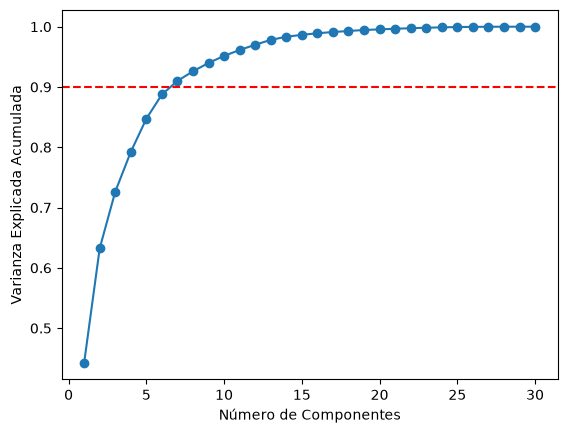

Componentes para 90%: 7
Componentes para 95%: 10


In [46]:
import numpy as np
import matplotlib.pyplot as plt

Xc_esc = StandardScaler().fit_transform(Xc)
pca_full = PCA().fit(Xc_esc)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.show()

print("Componentes para 90%:", np.argmax(var_acum >= 0.90) + 1)
print("Componentes para 95%:", np.argmax(var_acum >= 0.95) + 1)

**Responde aquí:** explica con tus palabras qué significa que 7 componentes expliquen ~91 % de la
varianza. ¿Qué dice eso sobre las 30 features originales?

> *(tu respuesta)*

In [ ]:
Que poquitas componentes expliquen más del 90% de la varianza significa que las 30 características originales están muy correlacionadas y tienen mucha información repetida. El dataset aparenta ser grande, pero en la práctica se mueve en un espacio mucho más chico.

### B4 · Selección o extracción: la decisión (3 pts)

**Contexto:** el modelo se va a usar en un hospital como apoyo al diagnóstico, y el equipo médico
exige poder explicar en qué se basó cada predicción.

**Responde aquí:** ¿recomendarías `SelectKBest` o PCA en este contexto? Justifica usando el
trade-off del capítulo. Menciona un contexto distinto en el que recomendarías lo contrario.

> *(tu respuesta)*

In [ ]:
En un entorno médico, se debe justificar cada predicción. Se sugiere usar SelectKBest porque mantiene las variables originales, ayudando a los médicos a entender el diagnóstico. En un contexto distinto, donde se busca reducir datos o aumentar la velocidad, se recomienda usar PCA, sin preocuparse por su significado físico.

### B5 · Por qué el Pipeline (3 pts)

Considera estas dos formas de evaluar la versión con `SelectKBest`:

```python
# Versión A
X_esc = StandardScaler().fit_transform(Xc)
X_sel = SelectKBest(f_classif, k=5).fit_transform(X_esc, yc)
scores_A = cross_val_score(KNeighborsClassifier(), X_sel, yc, cv=cv)

# Versión B
pipe = Pipeline([("sc", StandardScaler()),
                 ("sel", SelectKBest(f_classif, k=5)),
                 ("knn", KNeighborsClassifier())])
scores_B = cross_val_score(pipe, Xc, yc, cv=cv)
```

**Tu tarea:** ejecuta ambas y compara los promedios.

In [47]:
X_esc = StandardScaler().fit_transform(Xc)
X_sel = SelectKBest(f_classif, k=5).fit_transform(X_esc, yc)
scores_A = cross_val_score(KNeighborsClassifier(), X_sel, yc, cv=cv)

pipe = Pipeline([("sc", StandardScaler()), ("sel", SelectKBest(f_classif, k=5)), ("knn", KNeighborsClassifier())])
scores_B = cross_val_score(pipe, Xc, yc, cv=cv)

print("Scores A:", scores_A.mean())
print("Scores B:", scores_B.mean())

Scores A: 0.9473373699736065
Scores B: 0.9455674584691817


**Responde aquí:** una de las dos versiones tiene fuga de datos. ¿Cuál, y en qué momento exacto
ocurre? Explica qué hace el `Pipeline` en cada fold que la otra versión no hace.

> *(tu respuesta)*

In [ ]:
La versión A tiene fuga de datos (data leakage) porque escaló y seleccionó usando todo el dataset completo antes de evaluar, filtrando información del test hacia el entrenamiento. El Pipeline evita esto haciendo que el preprocesamiento se calcule de forma exclusiva dentro de cada fold.

---
## Cierre

**Última pregunta (sin puntaje, pero léela):** de todo lo que hiciste en este notebook, ¿cuál de las
decisiones crees que habría cambiado más el resultado si la hubieras tomado mal? Anótalo en una
línea — lo conversamos en la clase del 23 de septiembre, cuando arranquemos la Unidad 2.

> *(tu respuesta)*

In [ ]:
La elección que podría haber alterado más el desenlace si se hace incorrectamente es no seguir la regla fundamental al escalar o filtrar antes de la división, ya que esto eleva de manera artificial los resultados, haciendo que se piense que el modelo es ideal cuando en verdad va a fallar.